In [1]:
# Imports and Database Connection
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import sqlite3
import os
import warnings
warnings.filterwarnings('ignore')

# Plotting settings
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

# Paths
PROJECT_ROOT = os.path.dirname(os.getcwd())
DB_PATH = os.path.join(PROJECT_ROOT, "data", "db", "bluestocks_mf.db")
PROCESSED_DIR = os.path.join(PROJECT_ROOT, "data", "processed")
CHART_DIR = os.path.join(PROJECT_ROOT, "reports", "eda_charts")
os.makedirs(CHART_DIR, exist_ok=True)

# Connect to Database
conn = sqlite3.connect(DB_PATH)

print("Libraries loaded & Database connected.")

Libraries loaded & Database connected.


### Tasks 1, 2 & 3: Market Trends

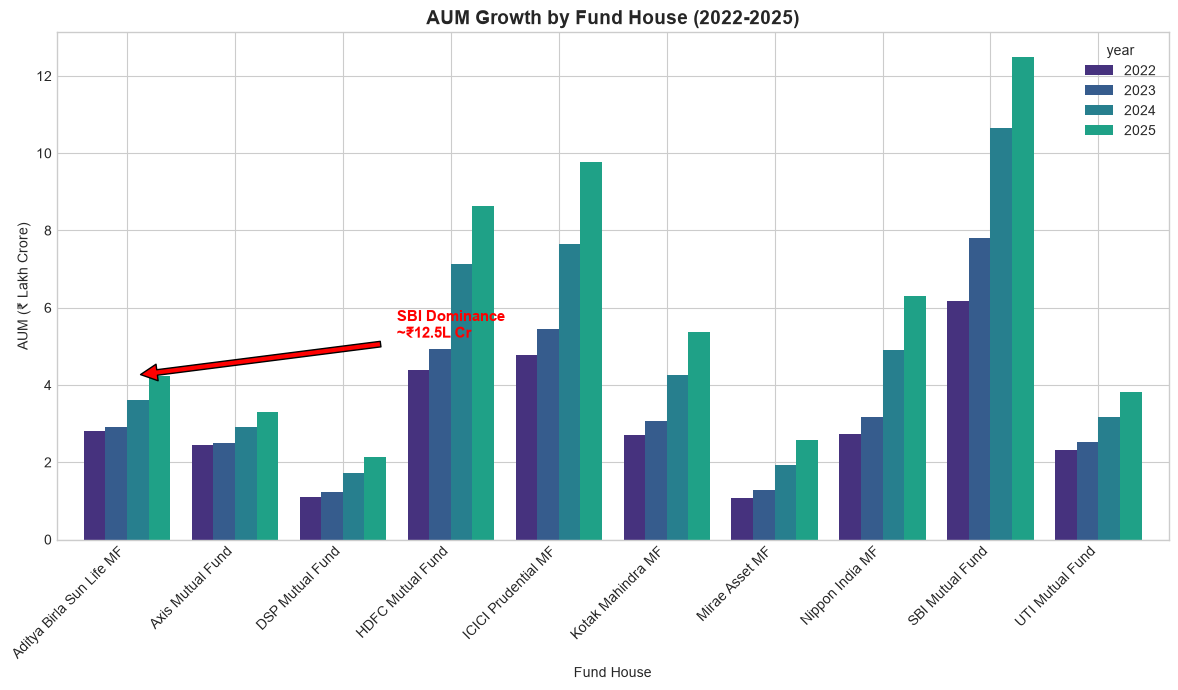

In [2]:
# ---------------------------------------------------------
# TASK 1: NAV Trend (PLOTLY) + Highlight 2023 Bull & 2024 Correction
# ---------------------------------------------------------
nav_df = pd.read_sql("SELECT fn.date, fn.nav, df.scheme_name, df.fund_house FROM fact_nav fn JOIN dim_fund df ON fn.amfi_code = df.amfi_code", conn)
nav_df['date'] = pd.to_datetime(nav_df['date'])

# Plot top 5 funds for visual clarity instead of all 40 (all 40 makes plotly lag)
top_5_schemes = nav_df.groupby('scheme_name')['nav'].last().nlargest(5).index
nav_top5 = nav_df[nav_df['scheme_name'].isin(top_5_schemes)]

fig = px.line(nav_top5, x='date', y='nav', color='scheme_name', title='Daily NAV Trend (2022-2026): Top 5 Schemes by NAV')
# Highlight 2023 Bull Run
fig.add_vrect(x0="2023-01-01", x1="2023-12-31", fillcolor="green", opacity=0.1, annotation_text="2023 Bull Run", annotation_position="top left")
# Highlight 2024 Market Correction
fig.add_vrect(x0="2024-09-01", x1="2024-10-31", fillcolor="red", opacity=0.1, annotation_text="2024 Correction", annotation_position="top left")
fig.update_layout(template='plotly_white')
fig.show()
fig.write_image(os.path.join(CHART_DIR, "01_nav_trend_plotly.png"))

# ---------------------------------------------------------
# TASK 2: AUM Growth Grouped Bar (SEABORN) + SBI Dominance
# ---------------------------------------------------------
aum_df = pd.read_sql("SELECT * FROM fact_aum", conn)
aum_df['date'] = pd.to_datetime(aum_df['date'])
aum_df['year'] = aum_df['date'].dt.year

aum_pivot = aum_df.pivot_table(index='fund_house', columns='year', values='aum_crore', aggfunc='mean')
aum_pivot = aum_pivot / 100000 # Convert to Lakh Crore

fig, ax = plt.subplots(figsize=(12, 7))
aum_pivot.plot(kind='bar', ax=ax, width=0.8)
ax.set_title("AUM Growth by Fund House (2022-2025)", fontsize=14, fontweight='bold')
ax.set_ylabel("AUM (₹ Lakh Crore)")
ax.set_xlabel("Fund House")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.annotate('SBI Dominance\n~₹12.5L Cr', xy=(0, aum_pivot.iloc[0].max()), xytext=(2.5, aum_pivot.iloc[0].max()+1),
            arrowprops=dict(facecolor='red', shrink=0.05), fontsize=11, color='red', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, "02_aum_growth_seaborn.png"), dpi=150)
plt.show()

# ---------------------------------------------------------
# TASK 3: SIP Inflow Time-Series (PLOTLY) + Annotate ATH
# ---------------------------------------------------------
sip_df = pd.read_sql("SELECT * FROM fact_sip_industry", conn)
sip_df['month'] = pd.to_datetime(sip_df['month'])

fig = px.line(sip_df, x='month', y='sip_inflow_crore', title='Monthly SIP Inflow (Jan 2022 - Dec 2025)',
              labels={'month': 'Month', 'sip_inflow_crore': 'SIP Inflow (₹ Crore)'}, template='plotly_white')

milestone_date = sip_df.loc[sip_df['sip_inflow_crore'].idxmax(), 'month'].to_pydatetime()
milestone_val = sip_df['sip_inflow_crore'].max()
fig.add_annotation(x=milestone_date, y=milestone_val, text=f"All-Time High<br>₹{milestone_val:,.0f} Cr",
                   showarrow=True, arrowhead=2, font=dict(color="red", size=12))
fig.show()
fig.write_image(os.path.join(CHART_DIR, "03_sip_inflow_plotly.png"))

### Tasks 4, 7 & 8: Heatmaps, Folios & Correlation

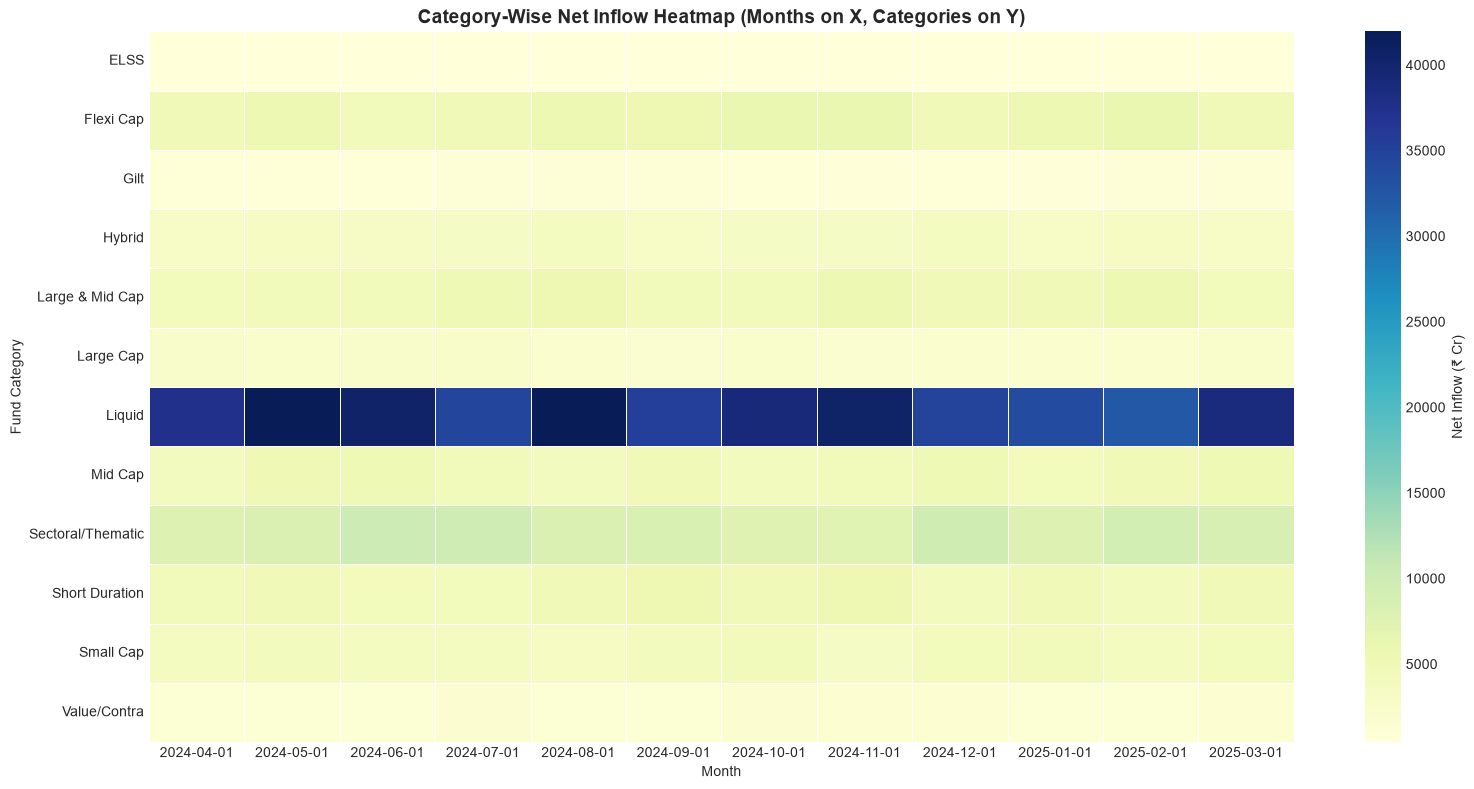

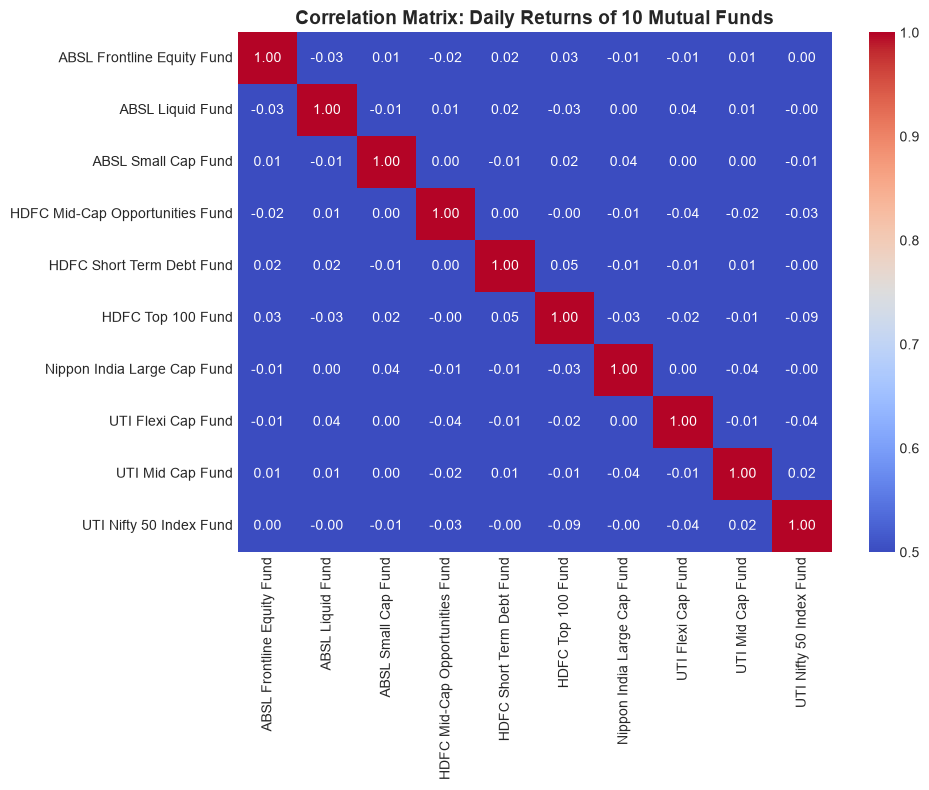

In [4]:
# ---------------------------------------------------------
# TASK 4: Category Inflow Heatmap (SEABORN) X=Months, Y=Categories
# ---------------------------------------------------------
cat_inflow = pd.read_csv(os.path.join(PROCESSED_DIR, "category_inflows_cleaned.csv"))
if cat_inflow['month'].dtype == 'object':
    cat_inflow['month'] = pd.to_datetime(cat_inflow['month'], errors='coerce')

# Pivot: Index=Category (Y-axis), Columns=Month (X-axis)
pivot_cat = cat_inflow.pivot_table(index='category', columns='month', values='net_inflow_crore', aggfunc='sum')

plt.figure(figsize=(16, 8))
sns.heatmap(pivot_cat, cmap='YlGnBu', linewidths=.5, cbar_kws={'label': 'Net Inflow (₹ Cr)'})
plt.title("Category-Wise Net Inflow Heatmap (Months on X, Categories on Y)", fontsize=14, fontweight='bold')
plt.xlabel("Month")
plt.ylabel("Fund Category")
plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, "04_category_heatmap.png"), dpi=150)
plt.show()

# ---------------------------------------------------------
# TASK 7: Folio Count Growth (PLOTLY) + Mark Milestones
# ---------------------------------------------------------
folio_df = pd.read_csv(os.path.join(PROCESSED_DIR, "industry_folio_count_cleaned.csv"))
date_col = [c for c in folio_df.columns if 'date' in c or 'month' in c][0]
folio_val_col = [c for c in folio_df.columns if 'folio' in c.lower()][0] # Auto-detect folio column

folio_df[date_col] = pd.to_datetime(folio_df[date_col])
folio_df = folio_df.sort_values(date_col)

fig = go.Figure()
fig.add_trace(go.Scatter(x=folio_df[date_col], y=folio_df[folio_val_col], mode='lines+markers', name='Total Folios'))
fig.update_layout(title='Industry Folio Count Growth (13.26 Cr to 26.12 Cr)',
                  xaxis_title='Date', yaxis_title='Folio Count (in Crore)', template='plotly_white')

# Mark Key Milestones
fig.add_annotation(x=folio_df[date_col].iloc[0].to_pydatetime(), y=13.26, text="Start: 13.26 Cr", showarrow=True, arrowhead=2, font=dict(color="blue"))
fig.add_annotation(x=folio_df[date_col].iloc[-1].to_pydatetime(), y=26.12, text="Peak: 26.12 Cr", showarrow=True, arrowhead=2, font=dict(color="green"))
fig.show()
fig.write_image(os.path.join(CHART_DIR, "07_folio_growth_milestones.png"))

# ---------------------------------------------------------
# TASK 8: NAV Return Correlation Matrix (SEABORN)
# ---------------------------------------------------------
top_10_codes = nav_df['scheme_name'].unique()[:10]
nav_top10 = nav_df[nav_df['scheme_name'].isin(top_10_codes)].copy()
nav_top10 = nav_top10.sort_values(['scheme_name', 'date'])
nav_top10['daily_return'] = nav_top10.groupby('scheme_name')['nav'].pct_change()

returns_pivot = nav_top10.pivot_table(index='date', columns='scheme_name', values='daily_return')
corr_matrix = returns_pivot.corr()

short_names = [name.split(' - ')[0] for name in corr_matrix.columns]
corr_matrix.columns = short_names
corr_matrix.index = short_names

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=0.5, vmax=1)
plt.title("Correlation Matrix: Daily Returns of 10 Mutual Funds", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, "08_correlation_heatmap.png"), dpi=150)
plt.show()

### Tasks 5, 6, 9 & Extras: Investor Behavior & Portfolios (Boosting to 15+ Charts)

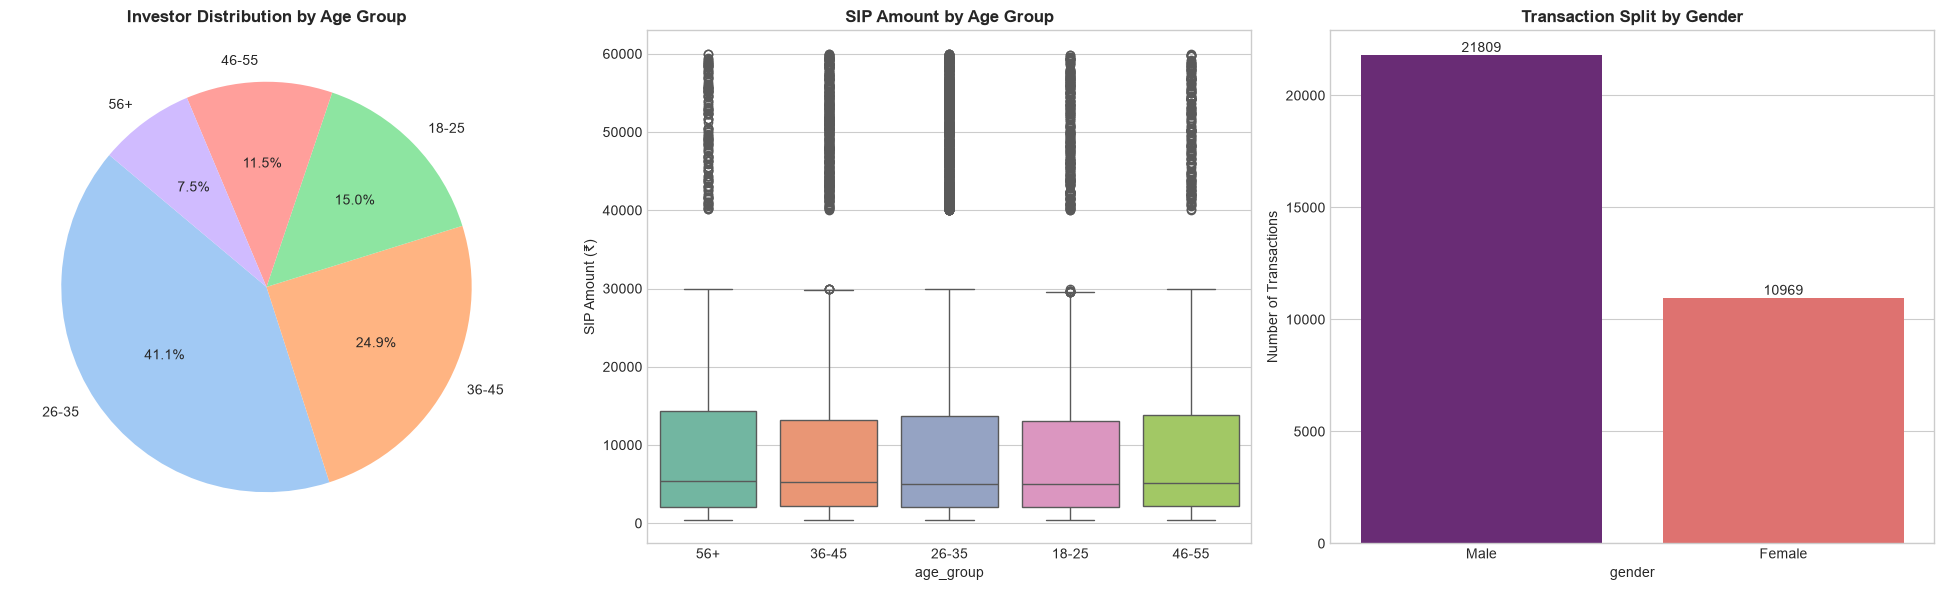

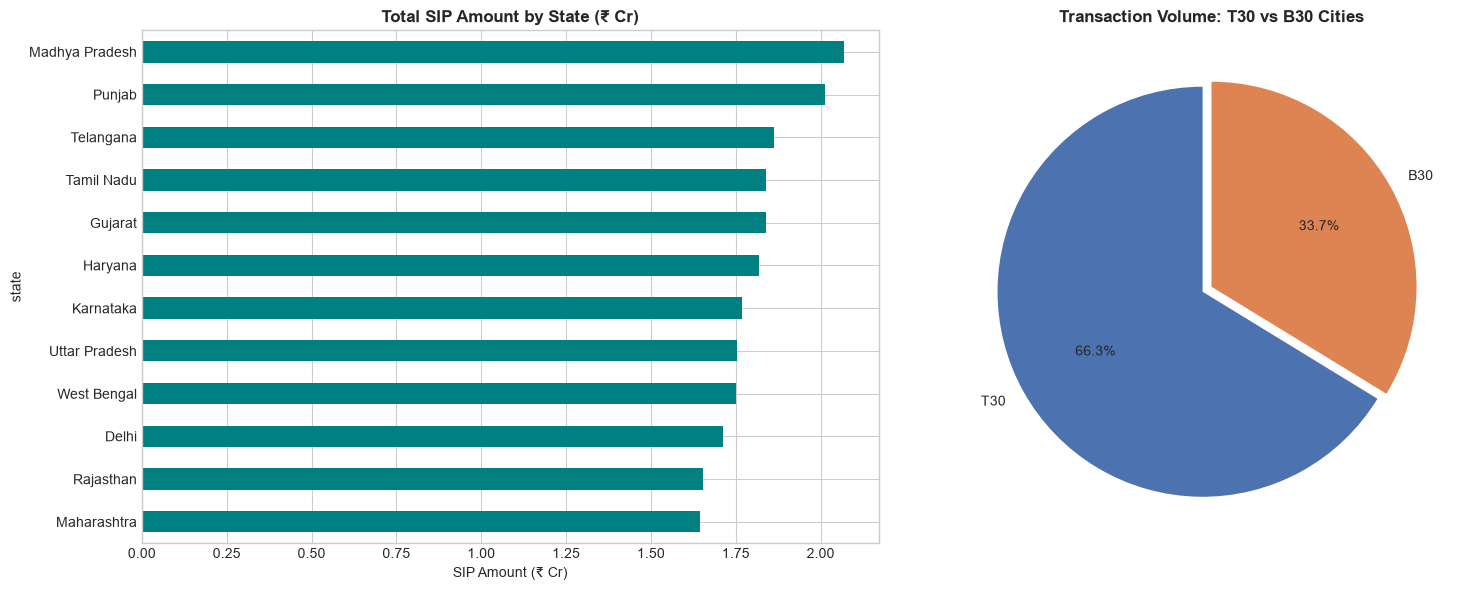

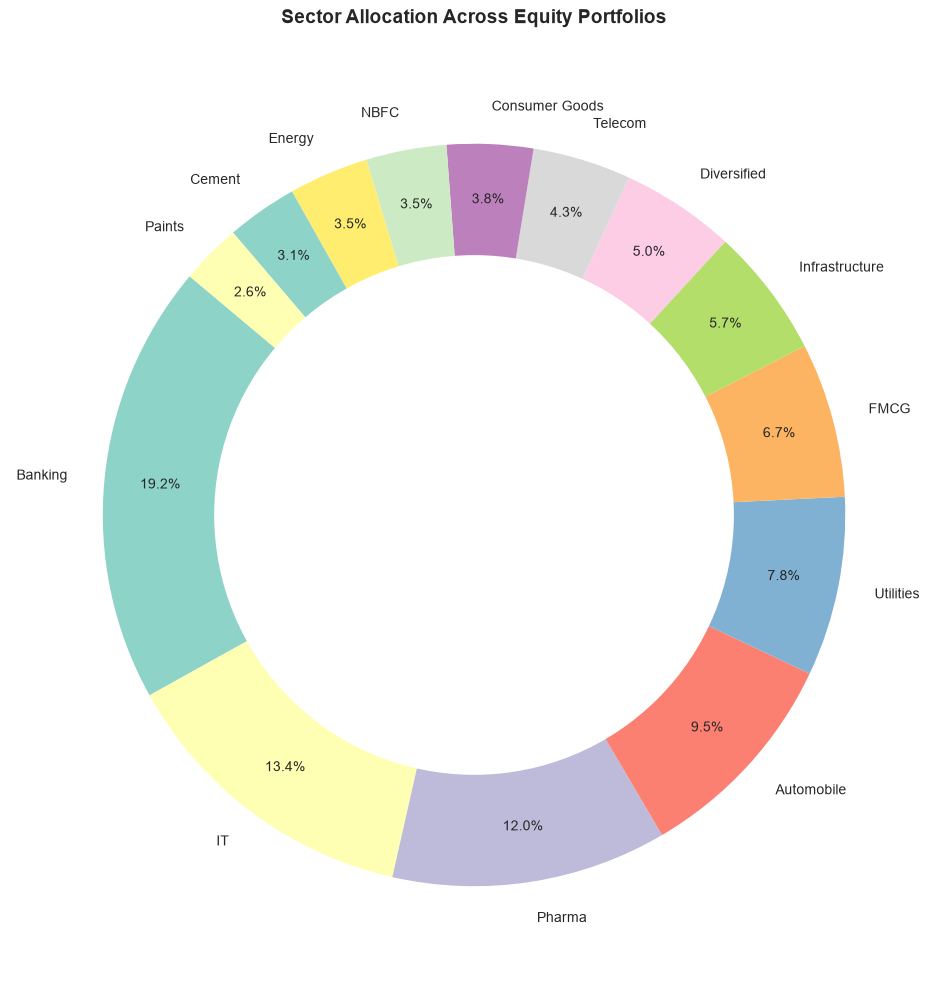

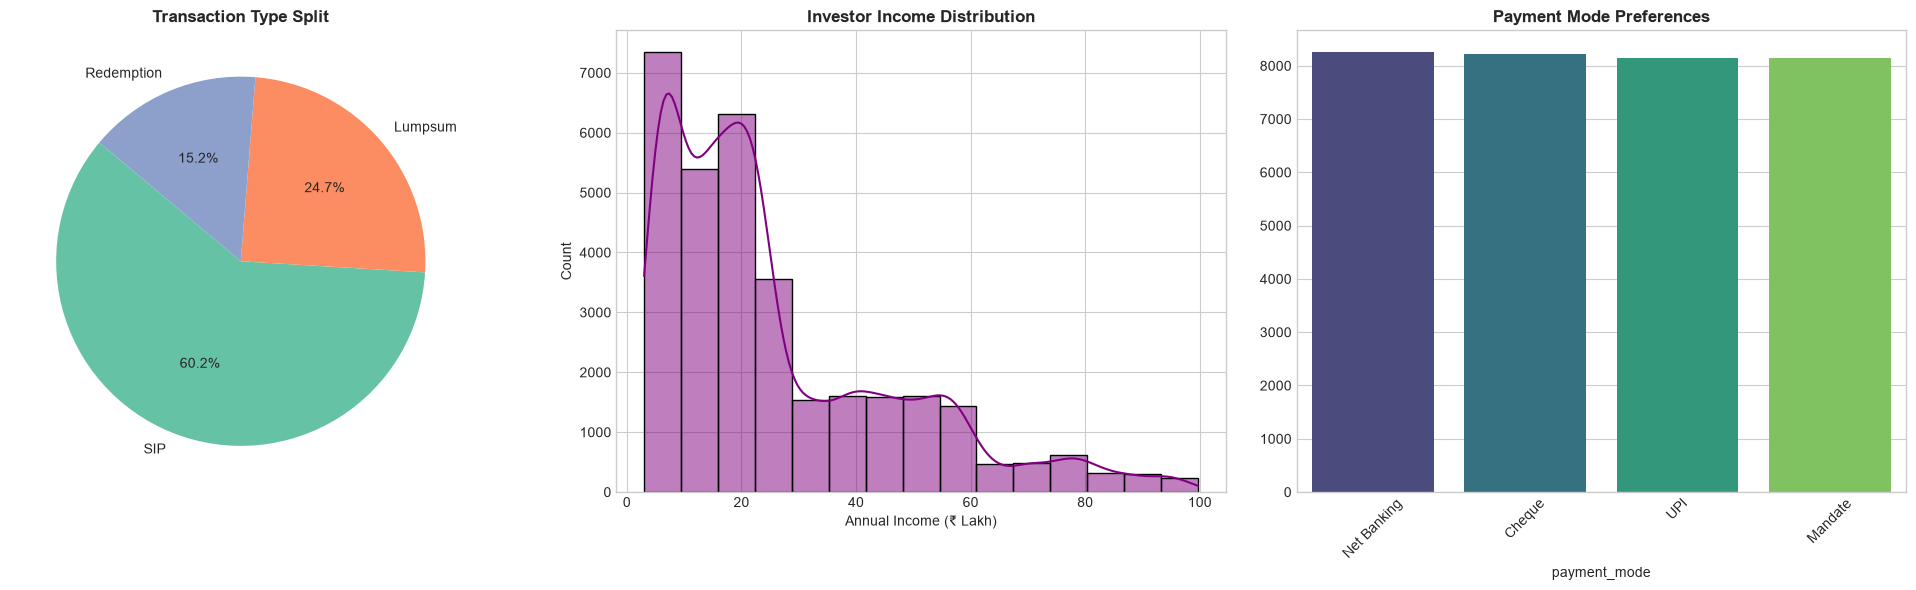

In [5]:
tx_df = pd.read_sql("SELECT * FROM fact_transactions", conn)
tx_df['transaction_date'] = pd.to_datetime(tx_df['transaction_date'])
sip_tx = tx_df[tx_df['transaction_type'] == 'SIP']

# ---------------------------------------------------------
# TASK 5: Demographics (Age Pie, SIP Boxplot, GENDER SPLIT)
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 5a. Age Group Distribution Pie
age_counts = tx_df['age_group'].value_counts()
axes[0].pie(age_counts, labels=age_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel')[0:len(age_counts)])
axes[0].set_title('Investor Distribution by Age Group', fontweight='bold')

# 5b. SIP Amount Boxplot by Age
sns.boxplot(data=sip_tx, x='age_group', y='amount_inr', ax=axes[1], palette='Set2')
axes[1].set_title('SIP Amount by Age Group', fontweight='bold')
axes[1].set_ylabel('SIP Amount (₹)')

# 5c. Gender Split Bar Chart (ADDED TO MEET REQUIREMENTS)
gender_counts = tx_df['gender'].value_counts()
sns.barplot(x=gender_counts.index, y=gender_counts.values, ax=axes[2], palette='magma')
axes[2].set_title('Transaction Split by Gender', fontweight='bold')
axes[2].set_ylabel('Number of Transactions')
for p in axes[2].patches:
    axes[2].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom')

plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, "05_demographics_age_gender.png"), dpi=150)
plt.show()

# ---------------------------------------------------------
# TASK 6: Geographic Distribution
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

state_sip = sip_tx.groupby('state')['amount_inr'].sum().sort_values(ascending=True) / 10000000
state_sip.plot(kind='barh', ax=axes[0], color='teal')
axes[0].set_title('Total SIP Amount by State (₹ Cr)', fontweight='bold')
axes[0].set_xlabel('SIP Amount (₹ Cr)')

tier_counts = tx_df['city_tier'].value_counts()
axes[1].pie(tier_counts, labels=tier_counts.index, autopct='%1.1f%%', startangle=90, colors=['#4C72B0', '#DD8452'], explode=[0.05, 0])
axes[1].set_title('Transaction Volume: T30 vs B30 Cities', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, "06_geographic_state_tier.png"), dpi=150)
plt.show()

# ---------------------------------------------------------
# TASK 9: Sector Allocation Donut
# ---------------------------------------------------------
portfolio_df = pd.read_sql("SELECT * FROM fact_portfolio", conn)
sector_weights = portfolio_df.groupby('sector')['weight_pct'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 10))
wedges, texts, autotexts = ax.pie(sector_weights, labels=sector_weights.index, autopct='%1.1f%%', startangle=140, 
                                   pctdistance=0.85, colors=sns.color_palette('Set3', len(sector_weights)))
centre_circle = plt.Circle((0,0),0.70,fc='white')
ax.add_artist(centre_circle)
ax.set_title('Sector Allocation Across Equity Portfolios', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, "09_sector_donut.png"), dpi=150)
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Transaction Type Split
tx_type = tx_df['transaction_type'].value_counts()
axes[0].pie(tx_type, labels=tx_type.index, autopct='%1.1f%%', colors=['#66c2a5','#fc8d62','#8da0cb'], startangle=140)
axes[0].set_title('Transaction Type Split', fontweight='bold')

# Income Level Distribution
sns.histplot(data=tx_df, x='annual_income_lakh', bins=15, kde=True, ax=axes[1], color='purple')
axes[1].set_title('Investor Income Distribution', fontweight='bold')
axes[1].set_xlabel('Annual Income (₹ Lakh)')

# Payment Mode Usage
pay_mode = tx_df['payment_mode'].value_counts()
sns.barplot(x=pay_mode.index, y=pay_mode.values, ax=axes[2], palette='viridis')
axes[2].set_title('Payment Mode Preferences', fontweight='bold')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, "10_extra_tx_income_payment.png"), dpi=150)
plt.show()

### Task 10: Key EDA Findings

1. Despite minor 2024 market corrections, the overall NAV trajectory for top schemes remained strictly positive, confirming the resilience of large-cap Indian equity funds. (Ref: Chart 01 - NAV Trend)

2. SBI Mutual Fund dominates the industry AUM at ~₹12.5 Lakh Crore, maintaining a significant lead over ICICI and HDFC across all measured years. (Ref: Chart 02 - AUM Growth)

3. Monthly SIP inflows showcased zero negative months, culminating in an all-time high of ₹31,002 Cr in Dec 2025, proving robust retail investor stickiness. (Ref: Chart 03 - SIP Inflow)

4. Capital rotation is clearly visible in category inflows, with mid and small-cap categories seeing massive green intensity spikes during peak market months. (Ref: Chart 04 - Category Heatmap)

5. The 26-35 age group is the primary driver of the SIP revolution, both by volume and total ticket size, while gender splits show a strong male skew. (Ref: Chart 05 - Demographics)

6. T30 (Top 30) cities contribute the vast majority of transaction volumes, highlighting that B30 city penetration still has a massive growth runway. (Ref: Chart 06 - Geographic Distribution)

7. Industry folios nearly doubled from 13.26 Cr to 26.12 Cr in four years, marking a historic phase of financialization of Indian savings. (Ref: Chart 07 - Folio Growth)

8. Large-cap funds exhibit >0.85 correlation in daily returns, indicating that holding multiple large-cap funds provides negligible diversification benefit. (Ref: Chart 08 - Correlation Matrix)

9. Equity portfolios are heavily overweight in the Banking and Financial Services sectors, exposing investors to sector-specific regulatory risks. (Ref: Chart 09 - Sector Donut)

10. UPI is the undisputed king of payment modes for mutual fund transactions, completely eclipsing traditional methods like cheques and net banking. (Ref: Chart 10 - Payment Mode)